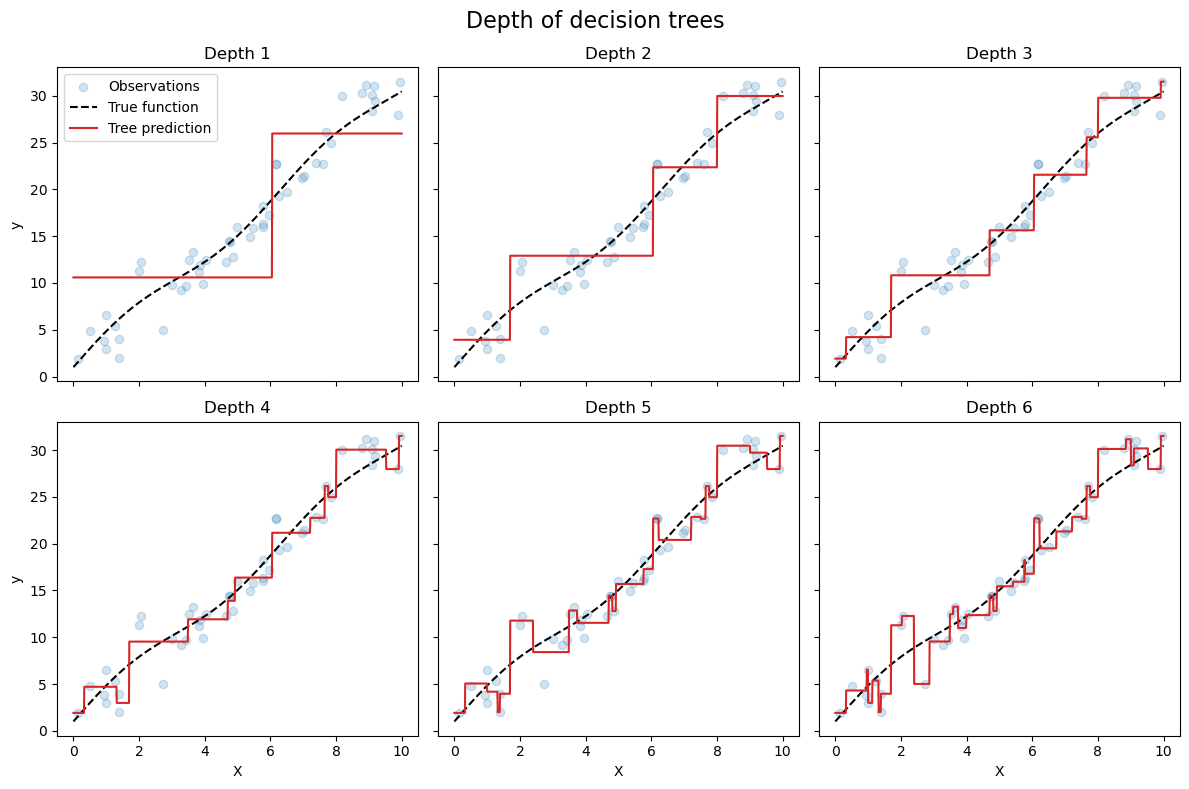

In [1]:
import numpy as np
from sklearn.tree import DecisionTreeRegressor
import matplotlib.pyplot as plt

# Generate synthetic data
rng = np.random.RandomState(1)
X = np.random.uniform(0, 10, size=50)
y = np.sin(X) + 3 * X + 1 + 2 * rng.randn(50)
true_fun = lambda X: np.sin(X) + 3 * X + 1

full_x = np.linspace(0, 10, 1000)
full_y = true_fun(full_x)
X = X.reshape(-1, 1)

# Fit regression model
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)

for idx, (ax, depth) in enumerate(zip(axes.flat, range(1, 7))):
    regr = DecisionTreeRegressor(max_depth=depth).fit(X, y)
    ax.scatter(X[:, 0], y, alpha=0.2, label='Observations' if idx == 0 else None)
    ax.plot(full_x, full_y, color='black', linestyle='--', label='True function' if idx == 0 else None)
    ax.plot(full_x, regr.predict(full_x[:, None]), color='tab:red', label='Tree prediction' if idx == 0 else None)
    ax.set_title(f'Depth {depth}')
    if idx == 0:
        ax.legend()

for ax in axes[-1]:
    ax.set_xlabel('X')
for ax in axes[:, 0]:
    ax.set_ylabel('y')

plt.suptitle("Depth of decision trees", fontsize=16)
fig.tight_layout()
plt.savefig("decision_tree_depth.png")
plt.show()

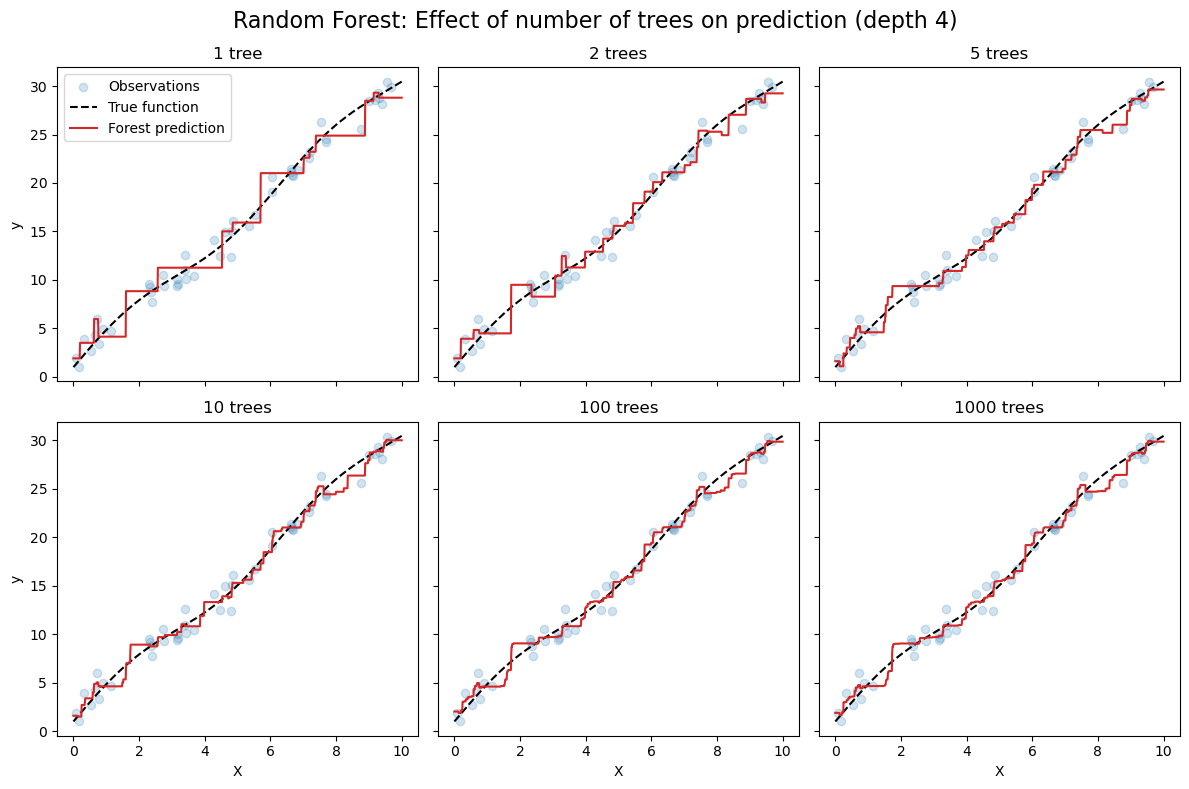

In [2]:
# Code for Random Forest
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# Generate synthetic data
rng = np.random.RandomState(1)
X = np.random.uniform(0, 10, size=50)
y = np.sin(X) + 3 * X + 1 + 1 * rng.randn(50)
true_fun = lambda X: np.sin(X) + 3 * X + 1

full_x = np.linspace(0, 10, 1000)
full_y = true_fun(full_x)
X = X.reshape(-1, 1)

# Fit regression model
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
tree_nums = [1, 2, 5, 10, 100, 1000]

for idx, (ax, num_trees) in enumerate(zip(axes.flat, tree_nums)):
    regr = RandomForestRegressor(n_estimators=num_trees, max_depth=4).fit(X, y)
    ax.scatter(X[:, 0], y, alpha=0.2, label='Observations' if idx == 0 else None)
    ax.plot(full_x, full_y, color='black', linestyle='--', label='True function' if idx == 0 else None)
    ax.plot(full_x, regr.predict(full_x[:, None]), color='tab:red', label='Forest prediction' if idx == 0 else None)
    ax.set_title(f'{num_trees} trees' if num_trees > 1 else '1 tree')
    if idx == 0:
        ax.legend()

for ax in axes[-1]:
    ax.set_xlabel('X')
for ax in axes[:, 0]:
    ax.set_ylabel('y')

plt.suptitle("Random Forest: Effect of number of trees on prediction (depth 4)", fontsize=16)
fig.tight_layout()
plt.savefig("random_forest_effect_of_trees.png")
plt.show()


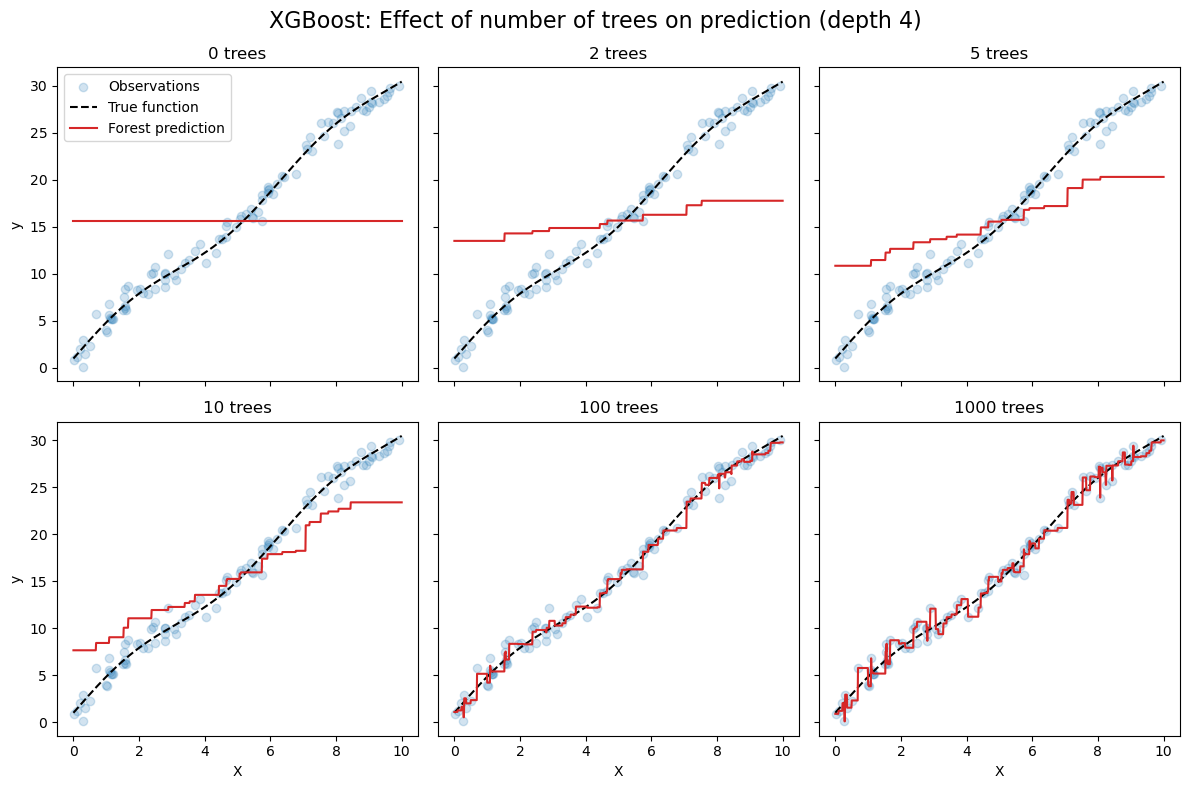

In [3]:
# Code for GBDT
# Generate a series of 4 graphs on top and 4 on bottom
# On top is the graph of what each individual tree is predicting at each step
# On bottom is the GBDT over time

# Code for Random Forest
import numpy as np
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import xgboost as xgb

# Generate synthetic data
rng = np.random.RandomState(1)
X = np.random.uniform(0, 10, size=100)
y = np.sin(X) + 3 * X + 1 + rng.randn(100)
true_fun = lambda X: np.sin(X) + 3 * X + 1

full_x = np.linspace(0, 10, 1000)
full_y = true_fun(full_x)
X = X.reshape(-1, 1)

# Fit regression model
fig, axes = plt.subplots(2, 3, figsize=(12, 8), sharex=True, sharey=True)
tree_nums = [0, 2, 5, 10, 100, 1000]

for idx, (ax, num_trees) in enumerate(zip(axes.flat, tree_nums)):
    if num_trees == 0:
        ax.scatter(X[:, 0], y, alpha=0.2, label='Observations')
        ax.plot(full_x, full_y, color='black', linestyle='--', label='True function')
        ax.plot(full_x, np.mean(y) * np.ones_like(full_x), color='tab:red', label='Forest prediction')
        ax.set_title('0 trees')
        ax.legend()
    else:
        regr = xgb.XGBRegressor(n_estimators=num_trees, max_depth=3, learning_rate=0.1).fit(X, y)
        ax.scatter(X[:, 0], y, alpha=0.2, label='Observations' if idx == 0 else None)
        ax.plot(full_x, full_y, color='black', linestyle='--')
        ax.plot(full_x, regr.predict(full_x[:, None]), color='tab:red')
        ax.set_title(f'{num_trees} trees' if num_trees > 1 else '1 tree')

for ax in axes[-1]:
    ax.set_xlabel('X')
for ax in axes[:, 0]:
    ax.set_ylabel('y')

plt.suptitle("XGBoost: Effect of number of trees on prediction (depth 4)", fontsize=16)
fig.tight_layout()
plt.savefig("xgb_effect_of_trees.png")
plt.show()